# Módulo 6 — Regresión
### Fundamentos de Computación Científica aplicada / Machine Learning

**Objetivo del módulo:** construir tu **primer algoritmo predictivo real**, uniendo dos cosas que ya conoces:

- El **cálculo y el gradiente descendente** que trabajamos en el Módulo 3.
- La **preparación de datos reales** que hicimos en el Módulo 5.

Con eso vamos a responder una pregunta muy concreta: *dado lo que sé de una observación (sus variables), ¿puedo predecir un número que todavía no conozco?*

**Contenido:**
1. Regresión lineal simple
2. Regresión lineal múltiple
3. Función de costo (MSE) y su conexión con el gradiente
4. Regresión con descenso de gradiente **implementado a mano**
5. Métricas de evaluación: R², MAE, RMSE
6. Aplicación real con datos de vivienda (California Housing)

> 💡 Idea central del módulo: **una regresión lineal es, literalmente, un problema de optimización** — buscamos los parámetros que minimizan el error. El "aprendizaje" no es magia, es cálculo aplicado.


## 0. Preparar el entorno

Vamos a usar librerías que ya conoces (`numpy`, `pandas`, `matplotlib`) más `scikit-learn`, que trae implementaciones ya optimizadas de regresión — las usaremos para **comparar** contra lo que programemos a mano.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

np.random.seed(42)
plt.rcParams["figure.figsize"] = (7, 4.5)
print("Librerías listas ✅")


Librerías listas ✅


## 1. Los datos: precios de vivienda en California

Vamos a trabajar con un dataset **real**: el censo de vivienda de California (datos del censo de EE. UU. de 1990, distribuido por `scikit-learn`). Cada fila es un **grupo de manzanas** (block group), no una casa individual, y describe:

| Variable | Significado |
|---|---|
| `MedInc` | Ingreso medio de los hogares (en decenas de miles de USD) |
| `HouseAge` | Edad media de las viviendas |
| `AveRooms` | Promedio de habitaciones por vivienda |
| `AveBedrms` | Promedio de dormitorios por vivienda |
| `Population` | Población del grupo |
| `AveOccup` | Promedio de ocupantes por vivienda |
| `Latitude` / `Longitude` | Ubicación geográfica |
| `MedHouseVal` | **Objetivo**: valor medio de la vivienda (en cientos de miles de USD) |

Esta es exactamente la lógica que vimos en el Módulo 5 con los datos de CORNARE: **datos reales, con su propia escala y ruido**, no datos inventados.


In [ ]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
df.head()


Filas: 20,640 | Columnas: 9


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
df.describe().T[["mean", "std", "min", "max"]]


,mean,std,min,max
MedInc,3.870671,1.899822,0.499900,15.000100
HouseAge,28.639486,12.585558,1.000000,52.000000
AveRooms,5.429000,2.474173,0.846154,141.909091
AveBedrms,1.096675,0.473911,0.333333,34.066667
Population,1425.476744,1132.462122,3.000000,35682.000000
AveOccup,3.070655,10.386050,0.692308,1243.333333
Latitude,35.631861,2.135952,32.540000,41.950000
Longitude,-119.569704,2.003532,-124.350000,-114.310000
MedHouseVal,2.068558,1.153956,0.149990,5.000010


**Lectura rápida:** fíjate en las escalas tan distintas — `MedInc` se mueve entre ~0.5 y 15, mientras que `Population` llega a decenas de miles. Esto **importa** para el descenso de gradiente, como veremos en la sección 3.


## 2. Regresión lineal simple

**Idea:** predecir el valor de la vivienda (`MedHouseVal`) usando **una sola variable**: el ingreso medio (`MedInc`), que intuitivamente debería tener buena relación con el precio.

El modelo que buscamos es la ecuación de una recta:

$$\hat{y} = w \cdot x + b$$

donde:
- $x$ = ingreso medio (`MedInc`)
- $\hat{y}$ = valor de vivienda predicho
- $w$ = pendiente (cuánto sube el precio por cada unidad de ingreso)
- $b$ = intercepto (valor base cuando el ingreso es 0)

**"Entrenar" el modelo = encontrar los mejores valores de $w$ y $b$.**


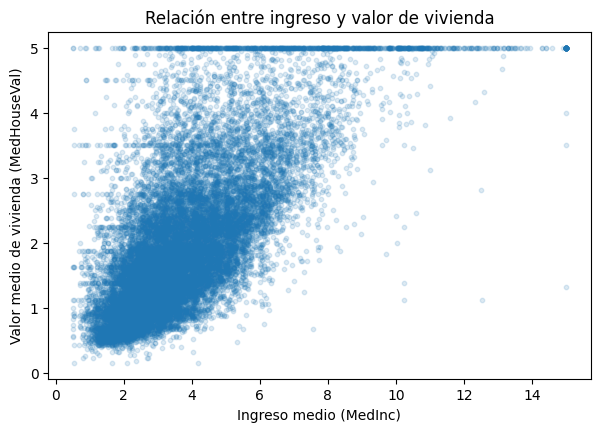

In [ ]:
x = df[["MedInc"]].values          # variable independiente (2D para sklearn)
y = df["MedHouseVal"].values       # variable objetivo

plt.scatter(x, y, alpha=0.15, s=10)
plt.xlabel("Ingreso medio (MedInc)")
plt.ylabel("Valor medio de vivienda (MedHouseVal)")
plt.title("Relación entre ingreso y valor de vivienda")
plt.show()


Se ve una tendencia creciente clara, con bastante dispersión (ruido, igual que en datos reales de sensores). Vamos a ajustar la recta con `scikit-learn` primero, para tener una referencia rápida.


In [ ]:
modelo_simple = LinearRegression()
modelo_simple.fit(x, y)

w = modelo_simple.coef_[0]
b = modelo_simple.intercept_
[5]
0 s
$0
print(f"Pendiente (w): {w:.4f}")
print(f"Intercepto (b): {b:.4f}")
print(f"\nEcuación del modelo: valor ≈ {w:.4f} × ingreso + {b:.4f}")


Pendiente (w): 0.4179
Intercepto (b): 0.4509

Ecuación del modelo: valor ≈ 0.4179 × ingreso + 0.4509


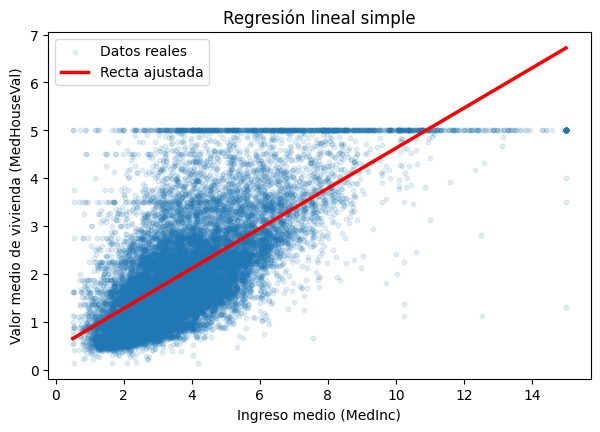

In [ ]:
x_linea = np.linspace(x.min(), x.max(), 100)
y_linea = w * x_linea + b

plt.scatter(x, y, alpha=0.12, s=10, label="Datos reales")
plt.plot(x_linea, y_linea, color="red", linewidth=2.5, label="Recta ajustada")
plt.xlabel("Ingreso medio (MedInc)")
plt.ylabel("Valor medio de vivienda (MedHouseVal)")
plt.legend()
plt.title("Regresión lineal simple")
plt.show()


**Interpretación:** por cada unidad adicional de ingreso medio (10,000 USD), el valor esperado de la vivienda sube aproximadamente `w` (en cientos de miles de USD). Esa es la utilidad de una regresión: **coeficientes interpretables**, no solo predicciones.


## 3. Función de costo (MSE) — la conexión con el Módulo 3

¿Cómo sabe `scikit-learn` cuál es la "mejor" recta? Necesita una forma de medir **qué tan mal** está prediciendo, para luego minimizar ese error.

Esa medida es el **Error Cuadrático Medio (MSE — Mean Squared Error)**:

$$J(w, b) = \frac{1}{n}\sum_{i=1}^{n}\left(\hat{y}_i - y_i\right)^2 = \frac{1}{n}\sum_{i=1}^{n}\left(w x_i + b - y_i\right)^2$$

- Elevamos al cuadrado para que errores positivos y negativos no se cancelen, y para penalizar más los errores grandes.
- $J(w, b)$ es una **función de dos variables** ($w$ y $b$): para cada combinación de pendiente e intercepto, obtenemos un costo distinto.

**Esto es exactamente el mismo tipo de función que optimizamos en el Módulo 3 con descenso de gradiente** — solo que ahora la función no es abstracta ($f(x) = x^2$), sino que mide el error de un modelo real.

Para encontrar el mínimo, necesitamos el **gradiente** de $J$ respecto a $w$ y $b$ (las mismas derivadas parciales del Módulo 3):

$$\frac{\partial J}{\partial w} = \frac{2}{n}\sum_{i=1}^{n}\left(w x_i + b - y_i\right) x_i \qquad\qquad \frac{\partial J}{\partial b} = \frac{2}{n}\sum_{i=1}^{n}\left(w x_i + b - y_i\right)$$

Y la regla de actualización es la misma de siempre:

$$w \leftarrow w - \alpha \frac{\partial J}{\partial w} \qquad\qquad b \leftarrow b - \alpha \frac{\partial J}{\partial b}$$

donde $\alpha$ es la tasa de aprendizaje (*learning rate*), igual que en Módulo 3.


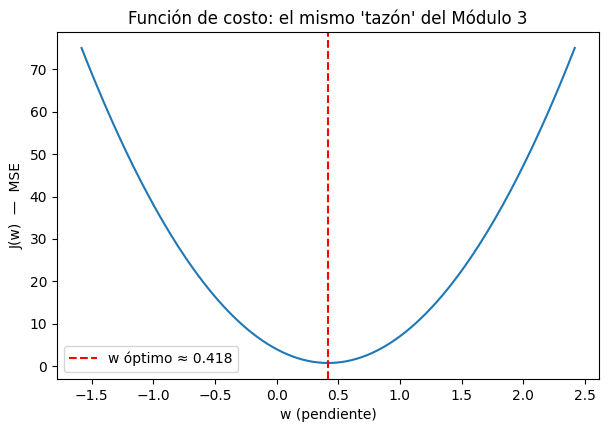

In [ ]:
def mse(w, b, x, y):
    y_pred = w * x + b
    return np.mean((y_pred - y) ** 2)

# Visualicemos J(w) dejando b fijo en el valor óptimo, para "ver" el tazón del Módulo 3
w_rango = np.linspace(w - 2, w + 2, 200)
costos = [mse(wi, b, x.flatten(), y) for wi in w_rango]

plt.plot(w_rango, costos)
plt.axvline(w, color="red", linestyle="--", label=f"w óptimo ≈ {w:.3f}")
plt.xlabel("w (pendiente)")
plt.ylabel("J(w)  —  MSE")
plt.title("Función de costo: el mismo 'tazón' del Módulo 3")
plt.legend()
plt.show()


Ahí está: la misma forma de parábola que vimos con $f(x) = x^2$ en el Módulo 3. El punto rojo es el mínimo — el valor de `w` que ya encontró `scikit-learn`. **Descenso de gradiente es literalmente "bajar" por esta curva.**


## 4. Regresión con descenso de gradiente — implementado a mano

Ahora vamos a reconstruir lo que `scikit-learn` hace internamente, usando **solo las fórmulas del Módulo 3**.

**Nota importante sobre escalas:** el ingreso (`MedInc`) tiene una escala pequeña y el valor de vivienda otra distinta. Cuando las variables tienen escalas muy diferentes, el descenso de gradiente puede volverse inestable (pasos gigantes en una dirección, minúsculos en otra). Por eso **estandarizamos** los datos antes de entrenar — una práctica estándar, no solo un detalle técnico.


In [ ]:
# Estandarización: media 0, desviación estándar 1
x_flat = x.flatten()
x_mean, x_std = x_flat.mean(), x_flat.std()
y_mean, y_std = y.mean(), y.std()

x_norm = (x_flat - x_mean) / x_std
y_norm = (y - y_mean) / y_std

print("Antes  -> media:", x_flat.mean().round(2), " std:", x_flat.std().round(2))
print("Después -> media:", x_norm.mean().round(2), " std:", x_norm.std().round(2))


Antes  -> media: 3.87  std: 1.9
Después -> media: 0.0  std: 1.0


In [ ]:
def descenso_gradiente(x, y, alpha=0.1, epochs=200):
    n = len(x)
    w, b = 0.0, 0.0          # inicialización (igual que Módulo 3)
    historial_costo = []

    for epoch in range(epochs):
        y_pred = w * x + b
        error = y_pred - y

        # Gradientes (derivadas parciales de J respecto a w y b)
        grad_w = (2 / n) * np.sum(error * x)
        grad_b = (2 / n) * np.sum(error)

        # Regla de actualización
        w -= alpha * grad_w
        b -= alpha * grad_b

        costo = np.mean(error ** 2)
        historial_costo.append(costo)

    return w, b, historial_costo

w_norm, b_norm, historial = descenso_gradiente(x_norm, y_norm, alpha=0.1, epochs=200)

print(f"w (normalizado): {w_norm:.4f}")
print(f"b (normalizado): {b_norm:.4f}")
print(f"Costo final (MSE): {historial[-1]:.5f}")


w (normalizado): 0.6881
b (normalizado): 0.0000
Costo final (MSE): 0.52655


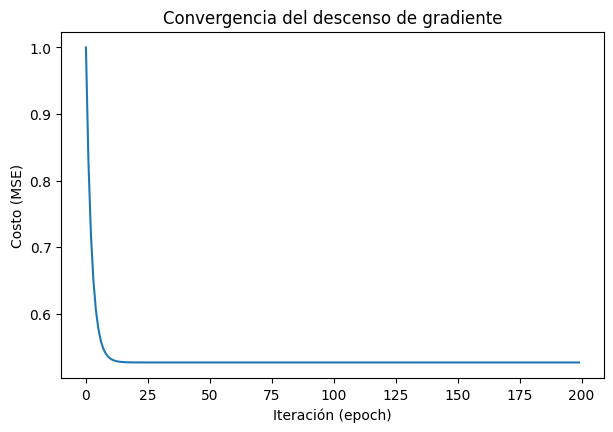

In [ ]:
plt.plot(historial)
plt.xlabel("Iteración (epoch)")
plt.ylabel("Costo (MSE)")
plt.title("Convergencia del descenso de gradiente")
plt.show()


Esa curva descendente **es** el algoritmo aprendiendo: en cada iteración, `w` y `b` se ajustan un poco en la dirección que más reduce el error, hasta estabilizarse cerca del mínimo.

**Verificación:** comparemos nuestro resultado (en escala normalizada) contra `scikit-learn` entrenado con los mismos datos normalizados. Deberían coincidir.


In [ ]:
modelo_check = LinearRegression()
modelo_check.fit(x_norm.reshape(-1, 1), y_norm)

print("=== Comparación ===")
print(f"Nuestro gradiente  -> w: {w_norm:.4f}  b: {b_norm:.4f}")
print(f"scikit-learn       -> w: {modelo_check.coef_[0]:.4f}  b: {modelo_check.intercept_:.4f}")


=== Comparación ===
Nuestro gradiente  -> w: 0.6881  b: 0.0000
scikit-learn       -> w: 0.6881  b: 0.0000


Si los valores son (casi) idénticos, confirmamos algo importante: **`LinearRegression()` de scikit-learn no hace magia** — bajo el capó, resuelve el mismo problema de optimización que acabamos de programar a mano (aunque usa un método analítico/numérico más eficiente que el descenso de gradiente puro).


## 5. Regresión lineal múltiple

En la práctica, casi nunca predecimos con una sola variable. El valor de una vivienda depende del ingreso, pero también de la edad de la vivienda, cuántas habitaciones tiene, dónde está ubicada, etc.

La ecuación se extiende de forma natural:

$$\hat{y} = w_1 x_1 + w_2 x_2 + \dots + w_k x_k + b$$

Cada variable tiene **su propio coeficiente** — su propia contribución a la predicción, manteniendo las demás constantes. Esto ya no lo implementamos a mano (el principio es el mismo, pero la notación matricial se sale del alcance del módulo); usamos `scikit-learn`, que generaliza exactamente el mismo algoritmo de optimización.


In [ ]:
features = ["MedInc", "HouseAge", "AveRooms", "AveBedrms", "Population", "AveOccup"]
X = df[features]
y = df["MedHouseVal"]

# Separamos en entrenamiento y prueba: entrenamos con una parte,
# evaluamos con datos que el modelo NUNCA vio (clave para saber si generaliza)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

modelo_multiple = LinearRegression()
modelo_multiple.fit(X_train, y_train)

coeficientes = pd.Series(modelo_multiple.coef_, index=features).sort_values()
coeficientes


,0
AveRooms,-0.223920
AveOccup,-0.004618
Population,0.000023
HouseAge,0.016788
MedInc,0.546161
AveBedrms,1.115493


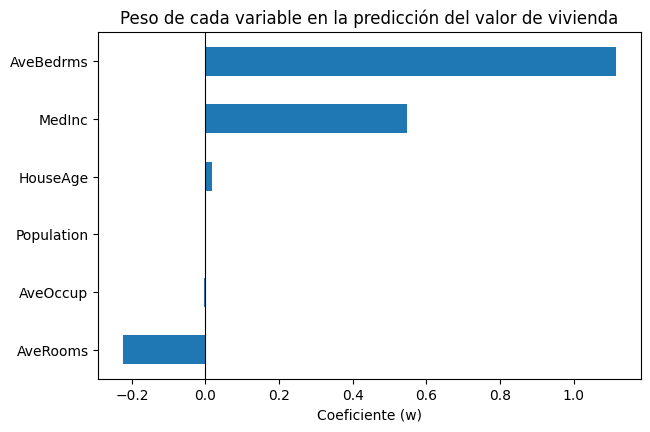

In [ ]:
coeficientes.plot(kind="barh")
plt.xlabel("Coeficiente (w)")
plt.title("Peso de cada variable en la predicción del valor de vivienda")
plt.axvline(0, color="black", linewidth=0.8)
plt.show()


**Lectura:** un coeficiente positivo grande (como `MedInc`) significa que esa variable empuja fuerte el precio hacia arriba; uno negativo (como `AveBedrms` en algunos ajustes) indica una relación inversa **una vez controladas las demás variables** — no siempre coincide con la intuición simple, y esa es justamente la ventaja de la regresión múltiple sobre mirar una variable a la vez.


## 6. Métricas de evaluación: ¿qué tan bueno es el modelo?

Con el modelo entrenado, necesitamos **medir su calidad** sobre datos de prueba (que no usó para entrenar). Tres métricas estándar:

**MAE — Error Absoluto Medio**
$$MAE = \frac{1}{n}\sum |\hat{y}_i - y_i|$$
Promedio del error en las mismas unidades que `y`. Fácil de interpretar: "en promedio, me equivoco en $X$ cientos de miles de USD".

**RMSE — Raíz del Error Cuadrático Medio**
$$RMSE = \sqrt{\frac{1}{n}\sum (\hat{y}_i - y_i)^2}$$
Es literalmente $\sqrt{MSE}$ — la misma función de costo del descenso de gradiente, pero en las unidades originales. Penaliza más los errores grandes que el MAE.

**R² — Coeficiente de determinación**
$$R^2 = 1 - \frac{\sum (\hat{y}_i - y_i)^2}{\sum (y_i - \bar{y})^2}$$
Indica **qué proporción de la variabilidad de `y` explica el modelo**. Va de (idealmente) 0 a 1: `R² = 1` es predicción perfecta, `R² = 0` equivale a predecir siempre el promedio.


In [ ]:
y_pred_test = modelo_multiple.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2 = r2_score(y_test, y_pred_test)

print("=== Desempeño en datos de PRUEBA (nunca vistos por el modelo) ===")
print(f"MAE  : {mae:.3f}   (cientos de miles de USD de error promedio)")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}   ({r2*100:.1f}% de la variabilidad explicada)")


=== Desempeño en datos de PRUEBA (nunca vistos por el modelo) ===
MAE  : 0.579   (cientos de miles de USD de error promedio)
RMSE : 0.801
R²   : 0.510   (51.0% de la variabilidad explicada)


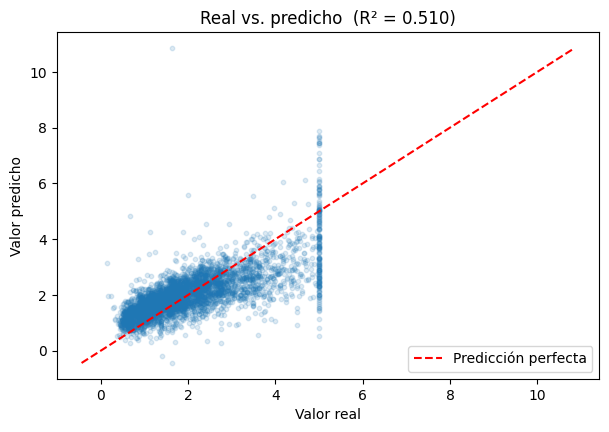

In [ ]:
plt.scatter(y_test, y_pred_test, alpha=0.15, s=10)
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
plt.plot(lims, lims, color="red", linestyle="--", label="Predicción perfecta")
plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.title(f"Real vs. predicho  (R² = {r2:.3f})")
plt.legend()
plt.show()


**Cómo leer este gráfico:** cuanto más pegados estén los puntos a la línea roja, mejor predice el modelo. La nube de puntos que se aleja arriba (valores reales altos que el modelo subestima) es una limitación conocida de este dataset: el valor de vivienda está truncado en 5.0 (500,000 USD) en los datos originales del censo — el modelo lineal no puede capturar ese "techo" artificial.

### Comparación simple vs. múltiple

Para cerrar el círculo, comparemos el modelo de **una sola variable** (sección 2) contra el de **múltiples variables** (sección 5), sobre el mismo conjunto de prueba.


In [ ]:
# Modelo simple entrenado solo con MedInc, evaluado en el mismo test set
modelo_simple_fair = LinearRegression()
modelo_simple_fair.fit(X_train[["MedInc"]], y_train)
pred_simple = modelo_simple_fair.predict(X_test[["MedInc"]])

comparacion = pd.DataFrame({
    "Modelo": ["Simple (solo MedInc)", "Múltiple (6 variables)"],
    "MAE":  [mean_absolute_error(y_test, pred_simple), mae],
    "RMSE": [np.sqrt(mean_squared_error(y_test, pred_simple)), rmse],
    "R2":   [r2_score(y_test, pred_simple), r2],
})
comparacion


,Modelo,MAE,RMSE,R2
0,Simple (solo MedInc),0.629909,0.842090,0.458859
1,Múltiple (6 variables),0.579214,0.801366,0.509934


Se espera que el modelo múltiple tenga **menor error y mayor R²**: más información relevante (a igual calidad) casi siempre mejora la predicción, aunque con retornos decrecientes.


## 7. Cierre y conexión con lo que sigue

**Lo que hicimos en este módulo:**

1. Ajustamos una **regresión lineal simple** con datos reales de vivienda.
2. Definimos la **función de costo MSE** y vimos que es la misma clase de función que optimizamos en el Módulo 3.
3. Implementamos **descenso de gradiente desde cero** y confirmamos que coincide con `scikit-learn`.
4. Extendimos el modelo a **regresión múltiple** con seis variables reales.
5. Evaluamos con **MAE, RMSE y R²**, comparando modelos entre sí sobre datos de prueba.

**Idea que debe quedar clara:** entrenar un modelo = definir una función de costo + minimizarla con gradiente. Esta misma lógica —cambiando la función de costo y la forma del modelo— es la base de casi todo lo que viene después (regresión logística, redes neuronales, etc.).

### Para practicar
- Prueba agregar `Latitude` y `Longitude` al modelo múltiple: ¿mejora el R²?
- Cambia el `learning rate` (`alpha`) del descenso de gradiente a mano: ¿qué pasa con la convergencia si es muy grande? ¿y si es muy pequeño?
- Repite el ejercicio de la sección 4 usando otra variable distinta a `MedInc` (por ejemplo `AveRooms`) y compara el MSE final.
